# Identifying Keywords About Climate Change

First, we will apply Latent Dirichlet Allocation (LDA) on Integovernmental Panel on Climate Change (IPCC) reports to extract keywords about climate change. LDA is a generative probabilistic model and view each document as random mixtures over latent topics, in which each topic is a probaiblity distribution over a fixed vocabulary. 
LDA can discover topics that the documents contain and the extent to which these topics are included in each document. Thus, it identifies words that are highly present in a large number of IPCC reports. 

## Loading Data

To illustrate the process of LDA, we will first test it on a report from the TCFD. 

In [ ]:
#To be run only the first time to download the libraries
!pip install spacy
!pip install gensim 
!pip install nltk

In [2]:
import nltk
nltk.download('stopwords')
import re
import numpy as np
from pprint import pprint
import spacy
from pandera.typing import DataFrame, DateTime, Object, Series
import pandera as pa
import gensim 
from nltk.corpus import stopwords
import gensim.corpora as corpora
import pandas as pd

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tlorans\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\tlorans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [83]:

filePath = '2021-Metrics_Targets_Guidance-1.txt'
report = sum(pd.read_table(filePath).values.tolist(), [])
report = ' '.join(report)
#split sentences
report = report.split('.')
print(len(report))
print(report[0:100])

2776
['Climate-related Financial Disclosures \x0c  Contents A', ' Overview and Background 1', ' Overview 2', ' Background B', ' Scope and Approach 1', ' Organizations in Scope 2', ' Approach 3', ' Key Considerations C', ' Climate-Related Metrics _ ', ' Characteristics of Effective Climate-Related Metrics ', ' Disclosing Climate-Related Metrics ', ' Driving Toward Comparability: Cross-Industry Metric Categories S © NN ', ' Portfolio Alignment Metrics for the Financial Sector D', ' Climate-Related Targets 1', ' Characteristics of Effective Climate-Related Targets 2', ' Disclosing Climate-Related Targets E', ' Transition Plans _ ', ' Characteristics of Effective Transition Plans N ', ' Transition Plan Considerations U ', ' Disclosing Transition Plan Information F', ' Financial Impacts 1', ' Inputs for Estimating Financial Impacts 2', ' Disclosing Financial Impacts Appendix 1: Further Information on Select Cross-Industry, Climate-Related Metric Categories 1', ' Scope 3 GHG Emissions 2', ' 

## Preprocessing


### Tokenizing

We need to tokenize the document into a list of words, remove the punctuations and unnecessary characters altogether. To do so, we will use Gensim's 'simple_preprocess()' function. Additionally, we have set 'deacc = True' to remove the punctuations.

In [33]:
def sent_to_words(sentences:list) -> list:
    return [gensim.utils.simple_preprocess(str(sent), deacc=True) for sent in sentences]

words = sent_to_words(report)
print(words[0:10])

[['climate', 'related', 'financial', 'disclosures', 'contents'], ['overview', 'and', 'background'], ['overview'], ['background'], ['scope', 'and', 'approach'], ['organizations', 'in', 'scope'], ['approach'], ['key', 'considerations'], ['climate', 'related', 'metrics'], ['characteristics', 'of', 'effective', 'climate', 'related', 'metrics']]


### Removing stopwords

We need to remove stopwords such as 'and', 'or', 'the'.

In [74]:
def remove_stopwords(sentences:list) -> list:
    stop_words = stopwords.words('english')
    stop_words.extend(['from', 'subject', 're', 'edu', 'use','www','pdf','company','https','tcfd'])
    text_out = []
    for sent in sentences:
        text_out.append([word for word in sent if word not in stop_words])
    return [sent for sent in text_out if len(sent) > 0]

report = remove_stopwords(words)
print(report[0:10])

[['climate', 'related', 'financial', 'disclosures', 'contents'], ['overview', 'background'], ['overview'], ['background'], ['scope', 'approach'], ['organizations', 'scope'], ['approach'], ['key', 'considerations'], ['climate', 'related', 'metrics'], ['characteristics', 'effective', 'climate', 'related', 'metrics']]


### Lemmatization

We next lemmatize each word to its root form, keeping only nouns. We want to keep only nouns because we are trying to extract the vocabulary regarding climate change risks.

In [ ]:
!python3 -m spacy download en # to be run only once 

In [75]:
def lemmatization(sentences:list, allowed_postags = ['NOUN']) -> list:
    nlp = spacy.load('en_core_web_sm', disable = ['parser','ner'])
    texts_out = []
    for sent in sentences:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return remove_stopwords(texts_out)

report = lemmatization(report)
print(report[0:10])

C:\Users\tlorans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\spacy\language.py:1895: UserWarning: [W123] Argument disable with value ['parser', 'ner'] is used instead of ['senter'] as specified in the config. Be aware that this might affect other components in your pipeline.
  warnings.warn(


[['climate', 'disclosure', 'content'], ['overview', 'background'], ['overview'], ['background'], ['scope', 'approach'], ['organization'], ['consideration'], ['climate', 'metric'], ['characteristic', 'climate', 'metric'], ['climate', 'metric']]


### Bigrams

Finally, we group words seen frequently next to each other, to get pairs of words (bigrams).

In [76]:
def make_bigrams(report:list) -> list:
    bigram = gensim.models.Phrases(report, min_count=1, threshold=50) # higher threshold fewer phrases.
    bigram_mod = gensim.models.phrases.Phraser(bigram)
    return [bigram_mod[sent] for sent in report]

report = make_bigrams(report)
print(report[0:10])

[['climate', 'disclosure', 'content'], ['overview_background'], ['overview'], ['background'], ['scope', 'approach'], ['organization'], ['consideration'], ['climate', 'metric'], ['characteristic', 'climate', 'metric'], ['climate', 'metric']]


## Exploratory Data Analysis

To get a sens of the result with our preprocessing, we'll make a word cloud using the wordcloud package. We'll get a visual representation of most common words.

In [11]:
from wordcloud import WordCloud

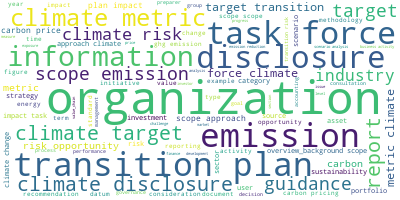

In [77]:
# Join the different processed titles together.
text = sum(report, [])
text = ','.join(text)
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(text)
# Visualize the word cloud
wordcloud.to_image()

## Build the Topic Model

To build a LDA model with Gensim, we need a corpus and a dictionary. 

In [78]:
id2word = corpora.Dictionary(report)
id2word.filter_extremes(no_below=15, no_above=0.1, keep_n=100000)

corpus = [id2word.doc2bow(sent) for sent in report]

In [79]:
lda_model = gensim.models.ldamodel.LdaModel(corpus = corpus,
                                            id2word = id2word, 
                                            num_topics = 5,
                                            random_state = 100,
                                            alpha = 'symmetric')
print(lda_model.print_topics())

[(0, '0.098*"force" + 0.093*"task" + 0.044*"report" + 0.043*"impact" + 0.038*"change" + 0.035*"asset" + 0.031*"plan" + 0.030*"recommendation" + 0.027*"information" + 0.025*"risk"'), (1, '0.165*"carbon" + 0.045*"price" + 0.033*"pricing" + 0.027*"scope" + 0.027*"risk" + 0.024*"investment" + 0.020*"plan" + 0.020*"asset" + 0.020*"portfolio" + 0.019*"information"'), (2, '0.130*"plan" + 0.100*"risk" + 0.077*"overview_background" + 0.035*"term" + 0.027*"asset" + 0.023*"carbon" + 0.021*"impact" + 0.018*"price" + 0.015*"investment" + 0.015*"science"'), (3, '0.144*"scope" + 0.059*"approach" + 0.049*"report" + 0.038*"information" + 0.028*"scenario" + 0.027*"risk" + 0.027*"impact" + 0.026*"category" + 0.025*"standard" + 0.020*"strategy"'), (4, '0.069*"risk" + 0.053*"impact" + 0.048*"business" + 0.046*"opportunity" + 0.032*"asset" + 0.030*"guidance" + 0.029*"sector" + 0.027*"activity" + 0.021*"change" + 0.020*"force"')]
